In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

old_set_bounds = mpl.patches.FancyBboxPatch.set_bounds # don't run this more than once!

In [2]:
import importlib
importlib.reload(snp)

<module 'snp' from '/Users/brian/Documents/ucsd/bimodal_plotting/sketch-neo-plot/src/snp.py'>

### STUDY ONE AND TWO

In [3]:
participants = ('P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10', 'Mean')
expert       = (0,     1,   0,     1,   1,    0,    1,     0,    1,    0,     0   )


interaction_counts = { 'Code': [5,  6, 12, 1,  15, 1,  6, 13, 4, 17],
                       'GUI':  [15, 0, 4,  2,  4,  10, 0, 5, 15, 13],
                       'AI':   [5,  7, 4,  11, 4,  4,  9, 23, 6, 7]  }

interaction_percentages = { 'Code': [8.7,  24.1, 50.5, 0.7,  20.4, 3.3,  19.6,   17.3, 27.6, 41.6],
                            'GUI':  [30.1, 0.0,  18.0, 5.7,  11.3, 60.7,  0.0,   6.5,  40.0, 20.0],
                            'AI':   [61.17, 75.9, 31.5, 93.6, 68.3, 36.0, 80.4, 76.2, 32.4, 38.4]  }


participants2 = ('P4', 'P7', 'P9', 'P10', 'Mean')

interaction_counts2 = { 'Code': [7, 54, 101, 38],
                        'GUI':  [85, 35, 58, 27],
                        'AI':   [54, 44, 16, 30]  }

interaction_times2 = { 'Code': [19.6, 136.8, 961.2, 287],
                       'GUI':  [330.7, 223.3, 194, 118.4],
                       'AI':   [1879.3, 1352, 440.7, 1455.9]  }


interaction_percentages2 = {}
modes = list(interaction_times2.keys())

for mode in modes:
    interaction_percentages2[mode] = []
    for participant_i in range(len(participants2) - 1):
        t = interaction_times2[mode][participant_i]
        total_t = sum(interaction_times2[m][participant_i] for m in modes)
        interaction_percentages2[mode].append(round(t / total_t * 100, 1))

for key in interaction_counts:
    vals = interaction_counts[key]
    interaction_counts[key].append(round(sum(vals) / len(vals), 1))
    vals2 = interaction_counts2[key]
    interaction_counts2[key].append(round(sum(vals2) / len(vals2), 1))

for key in interaction_percentages:
    vals = interaction_percentages[key]
    interaction_percentages[key].append(round(sum(vals) / len(vals), 1))
    vals2 = interaction_percentages2[key]
    interaction_percentages2[key].append(round(sum(vals2) / len(vals2), 1))
    

print(interaction_percentages2)

{'Code': [0.9, 8.0, 60.2, 15.4, 21.1], 'GUI': [14.8, 13.0, 12.2, 6.4, 11.6], 'AI': [84.3, 79.0, 27.6, 78.2, 67.3]}


In [4]:
# distance to infinitely long line passing through pt1 and pt2
def distance_to_line(pt, pt1, pt2):
    
    # translate so pt1 is 0,0
    x2 = pt2[0] - pt1[0]
    y2 = pt2[1] - pt1[1]
    x  = pt[0]  - pt1[0]
    y  = pt[1]  - pt1[1]

    # find unit vector
    segment_length = (x2**2 + y2**2)**0.5

    ux2 = x2 / segment_length
    uy2 = y2 / segment_length

    # project point onto line
    distance_from_origin_on_line = x*ux2 + y*uy2

    x_proj = ux2 * distance_from_origin_on_line
    y_proj = uy2 * distance_from_origin_on_line

    # distance to projection
    return ((x-x_proj)**2 + (y-y_proj)**2)**0.5


def goodness(code_amt, gui_amt, ai_amt, no_code_distance, no_gui_distance, no_ai_distance):
    amts                 = np.array([code_amt, gui_amt, ai_amt])
    distances_rev        = np.array([no_code_distance, no_gui_distance, no_ai_distance])
    amts_ratios          = amts / sum(amts)
    distances_rev_ratios = distances_rev / sum(distances_rev)
#     print(amts_ratios)
#     print(distances_rev_ratios)
    return sum(abs(distances_rev_ratios - amts_ratios))

In [5]:
tri_xs = [-0.5, 0,        0.5, -0.5]
tri_ys = [0,    3**0.5/2, 0  , 0]

tri_slope = 1/(3**0.5)

code_pt = (tri_xs[0], tri_ys[0])
gui_pt  = (tri_xs[1], tri_ys[1])
ai_pt   = (tri_xs[2], tri_ys[2])

def sign(x):
    if x < 0: return -1
    if x > 0: return 1
    return 0

In [6]:
def goodness2(pt, data, participant_i):
    no_gui_distance  = distance_to_line(pt, code_pt, ai_pt)
    no_ai_distance   = distance_to_line(pt, code_pt, gui_pt)
    no_code_distance = distance_to_line(pt, gui_pt,  ai_pt)

    code_amt = data['Code'][participant_i]
    gui_amt  = data['GUI'][participant_i]
    ai_amt   = data['AI'][participant_i]

    return goodness(code_amt, gui_amt, ai_amt, no_code_distance, no_gui_distance, no_ai_distance)


In [7]:
import random

def find_best(data, participant_i):
    pt = 0, 0.4
    dist = 10000

    while dist > 0.0001:
        dx = (random.random() - 0.5) * 0.01
        dy = (random.random() - 0.5) * 0.01
        
        new_pt = pt[0] + dx, pt[1] + dy
        
        if goodness2(new_pt, data, participant_i) < dist:
            pt = new_pt
            dist = goodness2(pt, data, participant_i)
#             print(dist)

#     print(participant_i, dist, pt)
    return pt

In [8]:
interaction_time_xs = []
interaction_time_ys = []

for participant_i in range(len(participants)):
    x, y = find_best(interaction_percentages, participant_i)
    interaction_time_xs.append(x)
    interaction_time_ys.append(y)

print(interaction_time_xs)
print(interaction_time_ys)

interaction_counts_xs = []
interaction_counts_ys = []

for participant_i in range(len(participants)):
    x, y = find_best(interaction_counts, participant_i)
    interaction_counts_xs.append(x)
    interaction_counts_ys.append(y)

print(interaction_counts_xs)
print(interaction_counts_ys)

[0.26238074428532127, 0.2590188854390077, -0.09500366597623917, 0.46451802971437245, 0.23950366759480554, 0.16352682509983035, 0.3040445114639485, 0.29449019989195924, 0.023980024582690038, -0.01602026320102252, 0.18999220289654598]
[0.2607543573476562, -1.5376688308001913e-05, 0.15584489586853256, 0.04939284111585443, 0.09790193726686082, 0.5256675365888562, -3.7541410749517256e-05, 0.05625089651639381, 0.3463685862473263, 0.17321301648647267, 0.1663009174048441]
[2.3369344769229305e-05, 0.038480543486507104, -0.20001525864293432, 0.35712455251264535, -0.2390871001336058, 0.09999502454532296, 0.10000974018833626, 0.12198772315487265, 0.03998339646673361, -0.1351253101099494, -1.6507532998790472e-05]
[0.5196020236731003, 2.592177998420999e-05, 0.1731790512304696, 0.12376066421931478, 0.15060463750646552, 0.5773882884047301, -3.9894240380202906e-05, 0.10559029510278796, 0.5196296938428208, 0.304261558113908, 0.2582481534873086]


In [9]:
interaction_time_xs2 = []
interaction_time_ys2 = []

for participant_i in range(len(participants2)):
    x, y = find_best(interaction_percentages2, participant_i)
    interaction_time_xs2.append(x)
    interaction_time_ys2.append(y)

print(interaction_time_xs2)
print(interaction_time_ys2)

interaction_counts_xs2 = []
interaction_counts_ys2 = []

for participant_i in range(len(participants2)):
    x, y = find_best(interaction_counts2, participant_i)
    interaction_counts_xs2.append(x)
    interaction_counts_ys2.append(y)

print(interaction_counts_xs2)
print(interaction_counts_ys2)

[0.41697795526367, 0.3549871618471207, -0.16301955713657149, 0.31399679373550626, 0.23095712065138424]
[0.12814002590295753, 0.11261104657992445, 0.10563092340938122, 0.05545987316717881, 0.10046577405465863]
[0.16097626554487507, -0.03754878460031939, -0.2428792748343254, -0.0420969671272139, -0.05101486296982921]
[0.5041786370243452, 0.2278936870088062, 0.28701572654495844, 0.24610897701770076, 0.32314789524185267]


In [10]:
import IPython
import time

/var/folders/gw/ntg0mn0j5qd5zwxmmg6vww880000gn/T/ipykernel_77555/4274910390.py:80: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  dot_white_outlines = ax.scatter(xs[:-1], ys[:-1], s=320, c=(1.00, 1.00, 1.00), zorder=2)


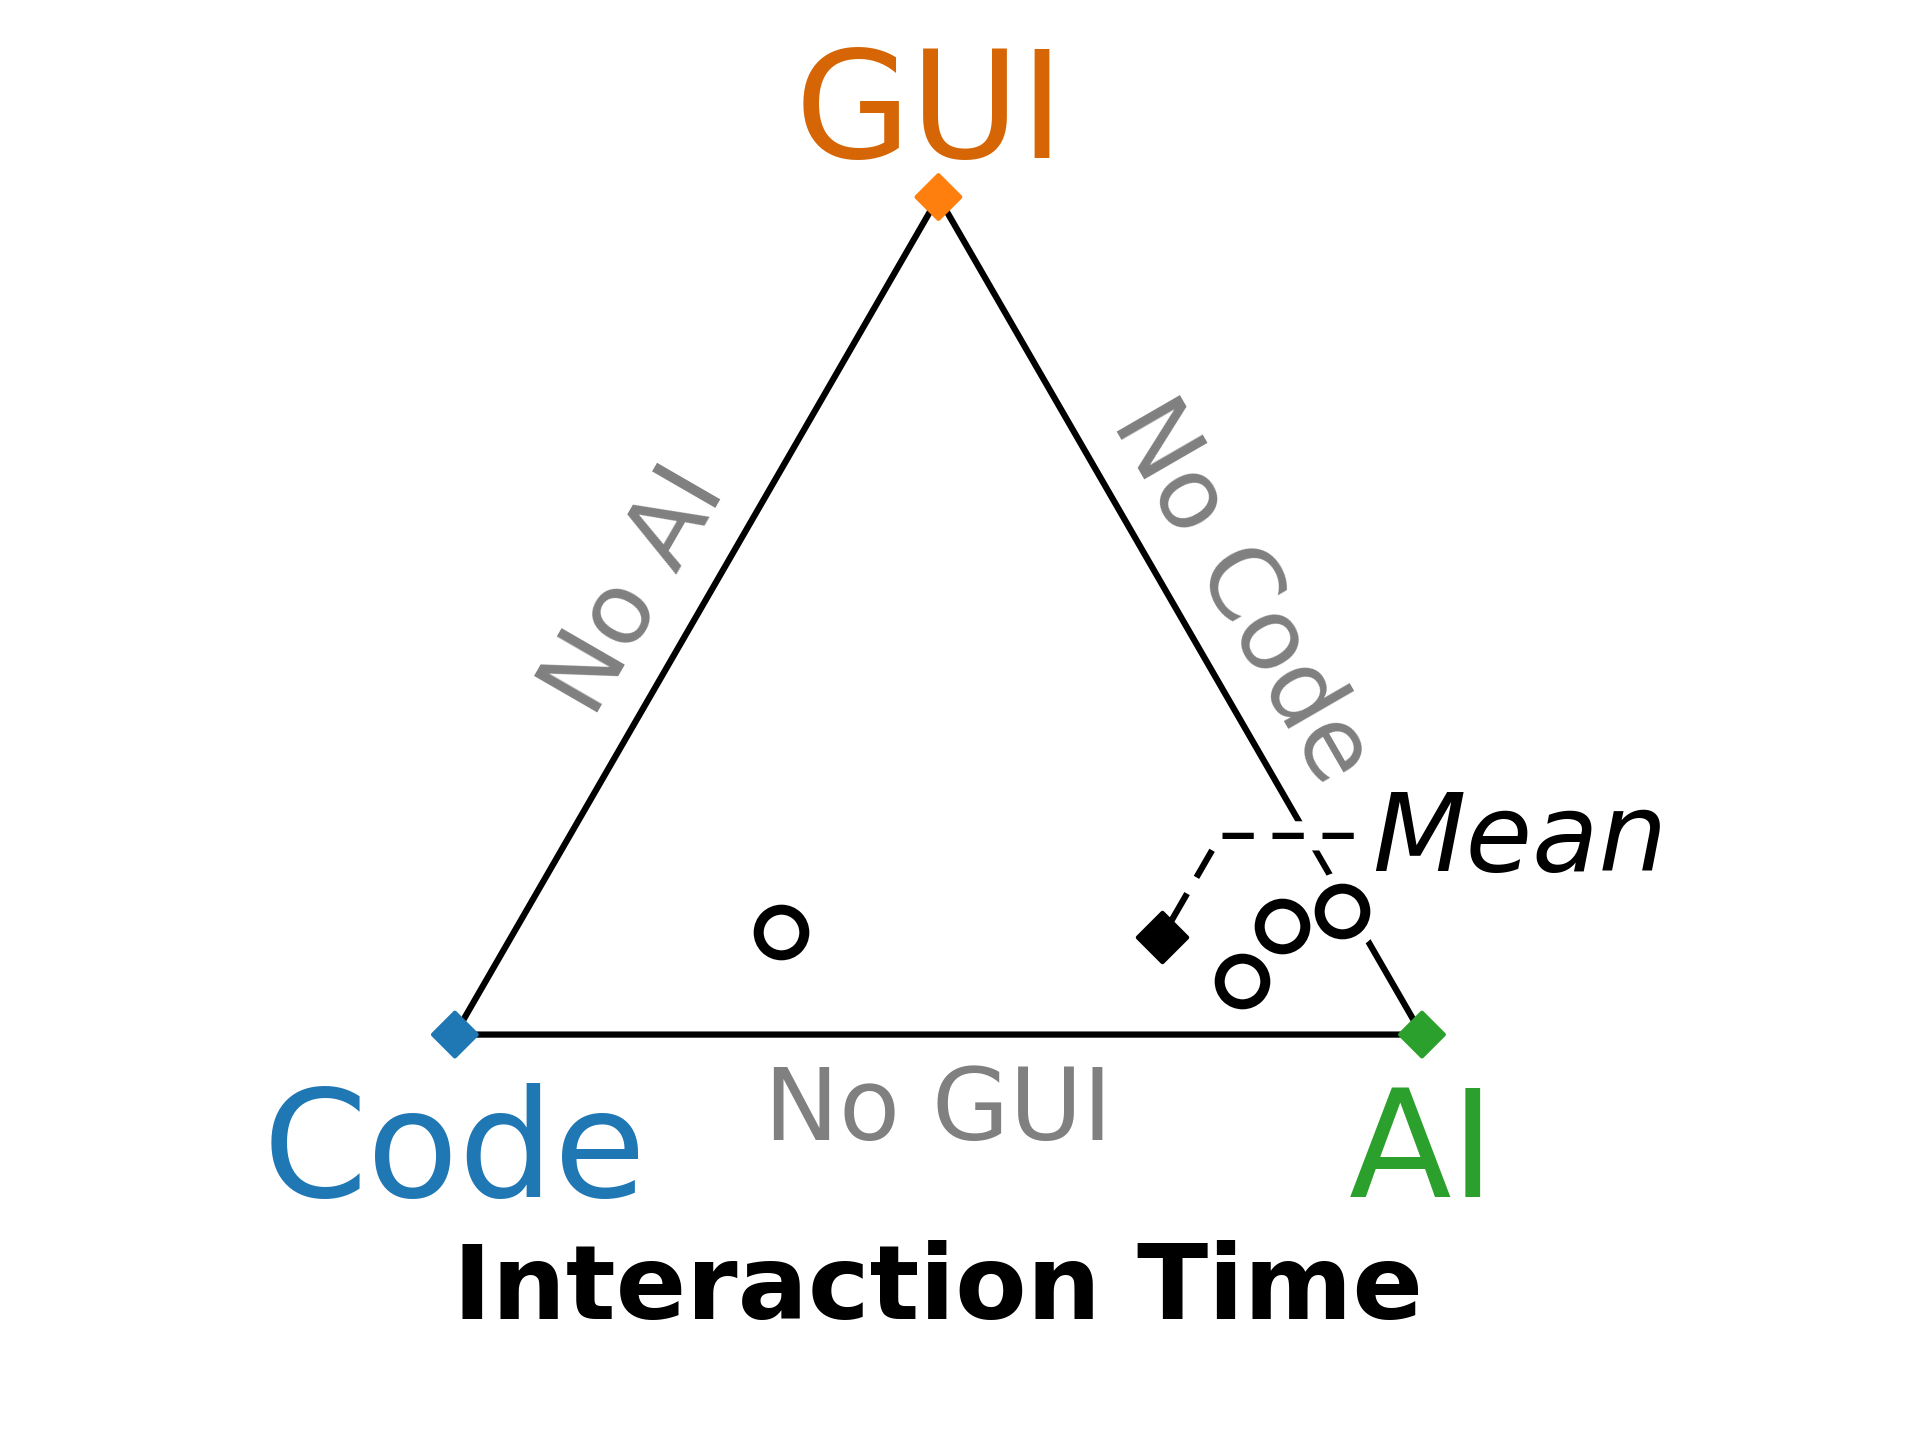

In [11]:
from matplotlib import patheffects
import matplotlib.patches as patches

# Hack to control bbox sizing
def new_set_bounds(self, x, y, w, h):
    return old_set_bounds(self, x, y, w, h*1.2)
mpl.patches.FancyBboxPatch.set_bounds = new_set_bounds


def tri_plot(title, participants, xs : list[float], ys : list[float], mean_label_offset : float):
    fig = plt.figure(layout='tight', facecolor=(1,1,1,0), dpi=300)
    ax = fig.add_subplot(1, 1, 1)

    # extracted this manually, of course
    border_color = 'black'
    edge_text_color = (0.5, 0.5, 0.5)

    # didn't have to look up the joinstyle docs to get the sharp corners, I would have guessed "sharp"
    ax.plot(tri_xs, tri_ys, color=border_color, solid_joinstyle='miter', linewidth=1.5)

    # Used AI for this line
    ax.set_aspect('equal', adjustable='box')

    # Learned this line from using AI for the overview example
    # entered manually here after AI gave too many lines of code for the same thing
    ax.axis('off')

    # was nice to be able to try out properties to e.g. toggle on rotation_mode
    # [dec 9, lisa] the three lines below were in comments before, so AI unexpectedly ate them. BAD
    text9 = ax.text(0.27, 3**0.5/4, 'No Code', color=edge_text_color, horizontalalignment='center', rotation=-60, verticalalignment='bottom', rotation_mode='anchor', fontsize=24)
    text11 = ax.text(-0.27, 3**0.5/4, 'No AI', color=edge_text_color, horizontalalignment='center', rotation=60, verticalalignment='bottom', rotation_mode='anchor', fontsize=24)
    # [dec 9, lisa] used drag and drop to reposition it to avoid text overlapping :)
    text12 = ax.text(0, -0.03, 'No GUI', color=edge_text_color, horizontalalignment='center', verticalalignment='top', fontsize=24)

    for i, name in reversed(list(enumerate(participants))):
        pass
        # [dec 9, lisa] AI wrote this part to separate letters and numbers from every name, very helpful
        # split text into two parts: alphabets and numbers
        alpha_part = ''.join(filter(str.isalpha, name))
        numeric_part = ''.join(filter(str.isdigit, name))

        # [dec 9, lisa] I wrote this conditional in code to handle special formatting for "Mean"
                        # however, plottery doesn't show layers within a conditional at all, so I can't use the GUI to tweak it
        if (alpha_part == 'Mean'):
            continue
            # text for letters with partial opacity
#             text_alpha = ax.text(xs[i], ys[i], alpha_part, horizontalalignment='center', verticalalignment='center', fontweight='bold', fontsize=14)
#             text_alpha.set_path_effects([patheffects.withStroke(linewidth=1, foreground='white')])

        # [dec 9, lisa] AI generated the code for bbox to adjust padding, which was very helpful
                        # I then used plottery to tweak the coloring and linewidth etc.
        # text for numbers with full opacity and smaller padding
        # text_numeric = ax.text(xs[i], ys[i], f'{alpha_part}{numeric_part}', horizontalalignment='center', verticalalignment='center', fontweight='normal', fontsize=14, bbox=dict(pad=2, edgecolor=(0, 0, 0, 1), facecolor='white', mutation_aspect=0.1))        

        # [sept 2 2025, brian] added this line by hand to get more control over the bbox positioning; bbox arg in above doesnt let us fine-tune the postion
#         text_numeric._bbox_patch = mpl.patches.FancyBboxPatch((0, 0), 1, 1, boxstyle='square,pad=0.2', edgecolor=(0, 0, 0, 1), facecolor='white')

    # Would be really nice to link properties, e.g. fontsize here (Sketch-n-Sketch Make Equal)
    text4 = ax.text(tri_xs[1] + -0.009, tri_ys[1] + 0.04, 'GUI', fontsize=36, horizontalalignment='center', color=(0.84, 0.40, 0.02))
    text5 = ax.text(tri_xs[0], tri_ys[0] + -0.05, 'Code', fontsize=36, horizontalalignment='center', color='C0', verticalalignment='top')

    # Poor man's alignment: used slider for x after duplicating the above line
    text6 = ax.text(tri_xs[2], tri_ys[2] + -0.05, 'AI', fontsize=36, horizontalalignment='center', color='C2', verticalalignment='top')

    # text8 = ax.set_title(title, y=-0.29, fontsize=25, fontweight='demi')

    # [sept 2 2025, brian] Added/editted with GUI
    corner_dots = ax.scatter(tri_xs, tri_ys, facecolors=['C0', 'C1', 'C2', 'none'], zorder=2, s=55, marker='D')

    
    
    # [sept 2 2025, brian] Added these with GUI, a little bit of code editing
    mean_dot = ax.scatter(xs[-1], ys[-1], s=70, c='black', zorder=3, marker='D')
    mean_x = xs[-1]
    mean_y = ys[-1]
    mean_label_y = mean_y + mean_label_offset
    mean_label_x = mean_label_y*-0.3 + 0.51
    mean_corner_x = mean_x + tri_slope*abs(mean_label_offset)
    white_bk_line = ax.plot([mean_x, mean_corner_x, mean_label_x], [mean_y, mean_label_y, mean_label_y], color=(1.00, 1.00, 1.00), linewidth=7)
    dot_white_outlines = ax.scatter(xs[:-1], ys[:-1], s=320, c=(1.00, 1.00, 1.00), zorder=2)
    mean_line = ax.plot([mean_x + 0.01, mean_corner_x, mean_label_x - 0.002], [mean_y + 0.01*(1/tri_slope)*sign(mean_label_offset), mean_label_y, mean_label_y], color=(0.00, 0.00, 0.00), linewidth=1.5, dashes=(5,3), zorder=2)
    mean_label = ax.text(mean_label_x, mean_label_y + -0.005, 'Mean', fontsize=26, verticalalignment='center', fontstyle='italic')
    dots = ax.scatter(xs[:-1], ys[:-1], s=120, c=[(0,0,0,0)], linewidths=2.4, edgecolors=(0.00, 0.00, 0.00), zorder=5)

    plt.show()

tri_plot('Interaction Counts', participants, interaction_counts_xs, interaction_counts_ys, 0)
tri_plot('Interaction Counts', participants2, interaction_counts_xs2, interaction_counts_ys2, -0.05)

tri_plot('Interaction Time', participants, interaction_time_xs, interaction_time_ys, 0)
tri_plot('Interaction Time', participants2, interaction_time_xs2, interaction_time_ys2, 0.105)
